# SafeBoda Trips: Price Variation by Time of Day and Day of Week

**Analysis Question:** *For my own SafeBoda trips, after controlling for distance, how do prices vary by time of day and day of week?*

**Context:** I very often use bodas to get around and spend a significant amount on them weekly. I use the SafeBoda app and have noticed that for similar routes (same distance), prices seem different depending on when I travel. I suspect this is driven by time of day and day of week — this notebook investigates that pattern.

**Sub-questions:**
1. What does my trip data look like overall?
2. How is price structured, and which metric best captures variation after controlling for distance?
3. How does price vary by time of day?
4. How does price vary by day of week?
5. What is the combined day × time pattern?
6. Are there specific windows where prices are noticeably higher?
7. Do these patterns confirm my suspicion?

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Data Overview

In [2]:
df = pd.read_csv('safeboda_trips.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (50, 22)


,trip_ref,date,time,pickup,dropoff,driver_name,trip_type,service_type,distance_km,duration_min,...,base_fare_ugx,min_fare_ugx,duration_cost_ugx,distance_cost_ugx,peak_hour_price_ugx,long_ride_charge_ugx,subtotal_ugx,ride_cost_ugx,payment_method,order_total_ugx
0,657e9542-4cfa-4297-9f93-5724b27e0e37,2026-03-26,18:48,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Luyirika Waswa husein,Bike,Ride,9,32,...,500,2000,950,2978,1550,447,6424,6500,Mobile_money,6669
1,db7dae87-939a-4dc6-9ef2-e09572a5cc01,2026-03-26,11:14,Dawson Kyaliwajjala Gas Station,ISBAT University,Paul Ayebare,Bike,Ride,11,20,...,500,2000,604,3376,672,7,5158,5000,Mobile_money,5130
2,e4344ace-7b62-4417-a66b-86d21fa4c8f7,2026-03-25,18:39,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Charles Kintu,Bike,Ride,9,24,...,500,2000,731,3005,1483,451,6169,6000,Mobile_money,6156
3,cee84c96-01ce-471a-afee-4be211eaf16c,2026-03-25,09:32,Dawson Kyaliwajjala Gas Station,ISBAT University,Joshua Mwambu,Bike,Ride,11,22,...,500,2000,672,3376,910,7,5464,5500,Mobile_money,5643
4,b11049df-440d-4115-9d06-140ae6184bd1,2026-03-23,18:51,Oryx Energies Lugogo,Dawson Kyaliwajjala Gas Station,Ashiraf Ssenfuka,Bike,Ride,9,29,...,500,2000,882,2964,1521,445,6312,6500,Mobile_money,6669


In [3]:
print('Column types:')
print(df.dtypes)
print()
df.describe()

Column types:
trip_ref                  str
date                      str
time                      str
pickup                    str
dropoff                   str
driver_name               str
trip_type                 str
service_type              str
distance_km             int64
duration_min            int64
price_per_minute_ugx    int64
price_per_km_ugx        int64
base_fare_ugx           int64
min_fare_ugx            int64
duration_cost_ugx       int64
distance_cost_ugx       int64
peak_hour_price_ugx     int64
long_ride_charge_ugx    int64
subtotal_ugx            int64
ride_cost_ugx           int64
payment_method            str
order_total_ugx         int64
dtype: object



,distance_km,duration_min,price_per_minute_ugx,price_per_km_ugx,base_fare_ugx,min_fare_ugx,duration_cost_ugx,distance_cost_ugx,peak_hour_price_ugx,long_ride_charge_ugx,subtotal_ugx,ride_cost_ugx,order_total_ugx
count,50.000000,50.000000,50.00000,50.000000,50.0,50.0,50.000000,50.000000,50.000000,50.000000,50.0000,50.000000,50.000000
mean,9.600000,24.320000,30.30000,323.300000,500.0,2000.0,737.620000,3077.440000,1135.320000,270.260000,5720.6200,5740.000000,5889.240000
std,1.355262,6.569689,1.19949,13.194387,0.0,0.0,199.924668,384.608423,394.835302,316.688014,692.6313,737.065334,756.229032
min,7.000000,10.000000,30.00000,320.000000,500.0,2000.0,296.000000,2179.000000,463.000000,0.000000,3879.0000,4000.000000,4104.000000
25%,9.000000,21.000000,30.00000,320.000000,500.0,2000.0,626.250000,2971.000000,688.250000,0.000000,5594.0000,5500.000000,5643.000000
50%,9.000000,24.000000,30.00000,320.000000,500.0,2000.0,732.000000,2990.000000,1070.500000,7.000000,5872.5000,6000.000000,6156.000000
75%,11.000000,29.000000,30.00000,320.000000,500.0,2000.0,881.750000,3376.000000,1521.750000,675.000000,6030.7500,6000.000000,6156.000000
max,11.000000,45.000000,35.00000,375.000000,500.0,2000.0,1363.000000,3956.000000,1754.000000,791.000000,6958.0000,7000.000000,7182.000000


## 2. Feature Engineering

We extract time-of-day and day-of-week features, and define time buckets for grouped analysis.

In [4]:
# Parse date and time
df['date'] = pd.to_datetime(df['date'])
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour
df['day_name'] = df['date'].dt.day_name()
df['day_num'] = df['date'].dt.dayofweek   # Monday=0, Sunday=6

# Time-of-day buckets
def time_bucket(hour):
    if 6 <= hour < 10:
        return 'Morning (6-10)'
    elif 10 <= hour < 14:
        return 'Midday (10-14)'
    elif 14 <= hour < 17:
        return 'Afternoon (14-17)'
    else:
        return 'Evening (17-20)'

df['time_bucket'] = df['hour'].apply(time_bucket)

# Ordered categories for clean chart axes
time_order = ['Morning (6-10)', 'Midday (10-14)', 'Afternoon (14-17)', 'Evening (17-20)']
day_order  = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

df['time_bucket'] = pd.Categorical(df['time_bucket'], categories=time_order, ordered=True)
df['day_name']    = pd.Categorical(df['day_name'],    categories=day_order,  ordered=True)

print('Trip counts by time bucket:')
print(df['time_bucket'].value_counts().sort_index())
print()
print('Trip counts by day:')
print(df['day_name'].value_counts().sort_index())

Trip counts by time bucket:
time_bucket
Morning (6-10)       10
Midday (10-14)       13
Afternoon (14-17)     5
Evening (17-20)      22
Name: count, dtype: int64

Trip counts by day:
day_name
Monday       10
Tuesday       0
Wednesday    12
Thursday     12
Friday       10
Saturday      0
Sunday        6
Name: count, dtype: int64


## 3. Understanding the Price Structure

SafeBoda's `order_total_ugx` is the amount I actually paid. The key components are:

| Column | Description |
|--------|-------------|
| `base_fare_ugx` | Fixed base fare |
| `distance_cost_ugx` | = distance_km × price_per_km_ugx |
| `duration_cost_ugx` | = duration_min × price_per_minute_ugx |
| `peak_hour_price_ugx` | **Surge charge applied at busy times** |
| `long_ride_charge_ugx` | Extra charge for long rides |

**Controlling for distance:** Since I mostly travel the same two routes (7 km, 9 km, or 11 km), I'll use two complementary metrics:
1. **`peak_hour_price_ugx`** — the explicit surge component, independent of distance
2. **`price_per_km_actual`** = `order_total_ugx / distance_km` — effective price per km paid

In [5]:
# Verify price_per_km_ugx is flat (SafeBoda's formula rate)
print('price_per_km_ugx unique values:', df['price_per_km_ugx'].unique())
print('price_per_minute_ugx unique values:', df['price_per_minute_ugx'].unique())

# Compute actual effective price per km (controls for distance)
df['price_per_km_actual'] = df['order_total_ugx'] / df['distance_km']

print()
print('Distance distribution:')
print(df['distance_km'].value_counts())

print()
print('Mean order_total_ugx and peak_hour_price_ugx by distance:')
print(df.groupby('distance_km')[['order_total_ugx', 'peak_hour_price_ugx', 'price_per_km_actual']].mean().round(0))

price_per_km_ugx unique values: [320 375]
price_per_minute_ugx unique values: [30 35]

Distance distribution:
distance_km
9     23
11    21
7      6
Name: count, dtype: int64

Mean order_total_ugx and peak_hour_price_ugx by distance:
             order_total_ugx  peak_hour_price_ugx  price_per_km_actual
distance_km                                                           
7                     4275.0                990.0                611.0
9                     6178.0               1493.0                686.0
11                    6034.0                785.0                549.0


### 3a. Distance is the primary confound

Since trips vary in distance (7, 9, or 11 km), total price is heavily driven by distance. The charts below show this, motivating why we must control for distance in our analysis.

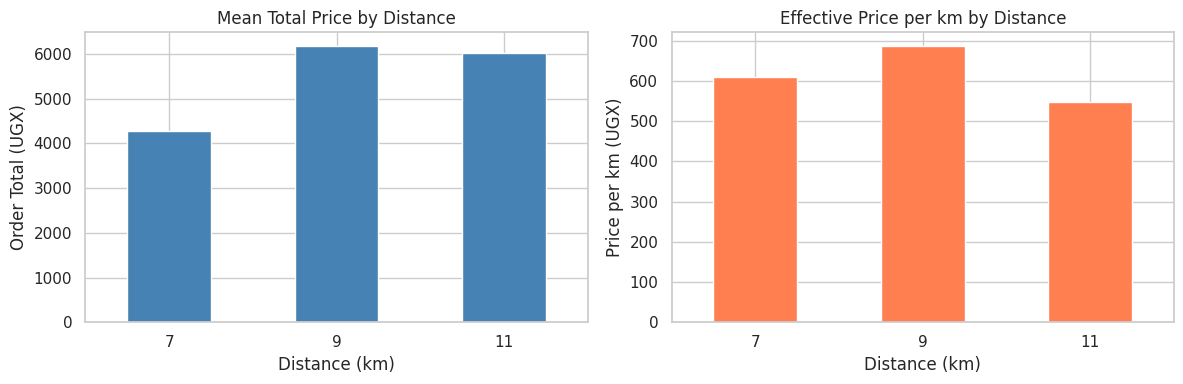

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Total price by distance
df.groupby('distance_km')['order_total_ugx'].mean().plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Mean Total Price by Distance')
axes[0].set_xlabel('Distance (km)')
axes[0].set_ylabel('Order Total (UGX)')

# Price per km actual by distance — should flatten out the distance effect
df.groupby('distance_km')['price_per_km_actual'].mean().plot(kind='bar', ax=axes[1], color='coral', rot=0)
axes[1].set_title('Effective Price per km by Distance')
axes[1].set_xlabel('Distance (km)')
axes[1].set_ylabel('Price per km (UGX)')

plt.tight_layout()
plt.show()

## 4. Price Variation by Time of Day

We compare the **peak_hour_price_ugx** (surge charge) and **effective price per km** across time-of-day buckets.

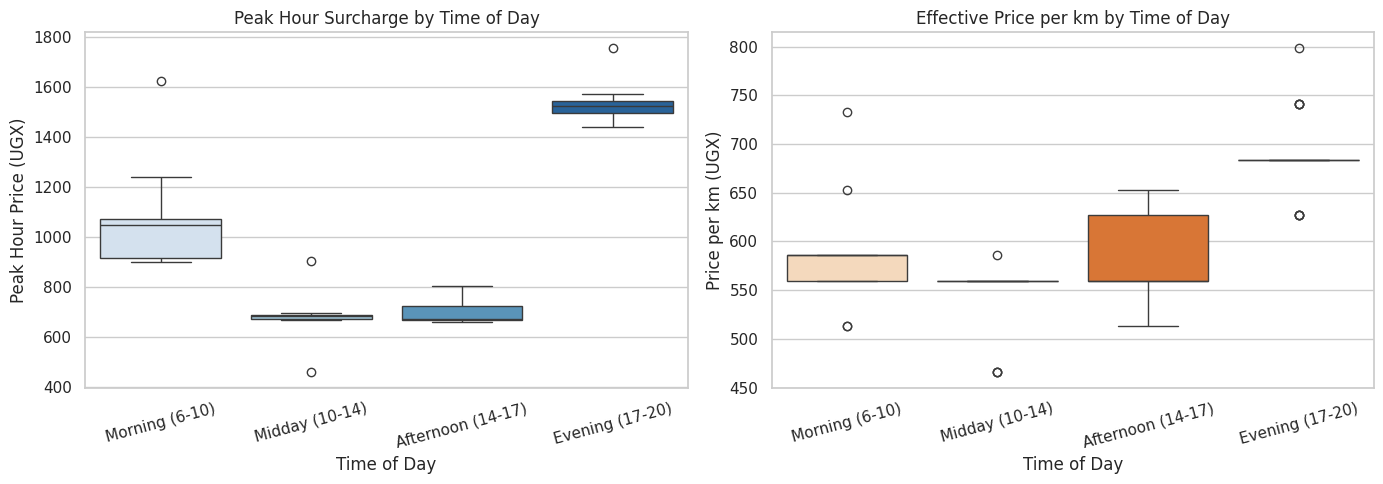

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Peak hour price by time bucket
sns.boxplot(
    data=df, x='time_bucket', y='peak_hour_price_ugx',
    order=time_order, ax=axes[0], palette='Blues'
)
axes[0].set_title('Peak Hour Surcharge by Time of Day')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Peak Hour Price (UGX)')
axes[0].tick_params(axis='x', rotation=15)

# Effective price per km by time bucket
sns.boxplot(
    data=df, x='time_bucket', y='price_per_km_actual',
    order=time_order, ax=axes[1], palette='Oranges'
)
axes[1].set_title('Effective Price per km by Time of Day')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Price per km (UGX)')
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

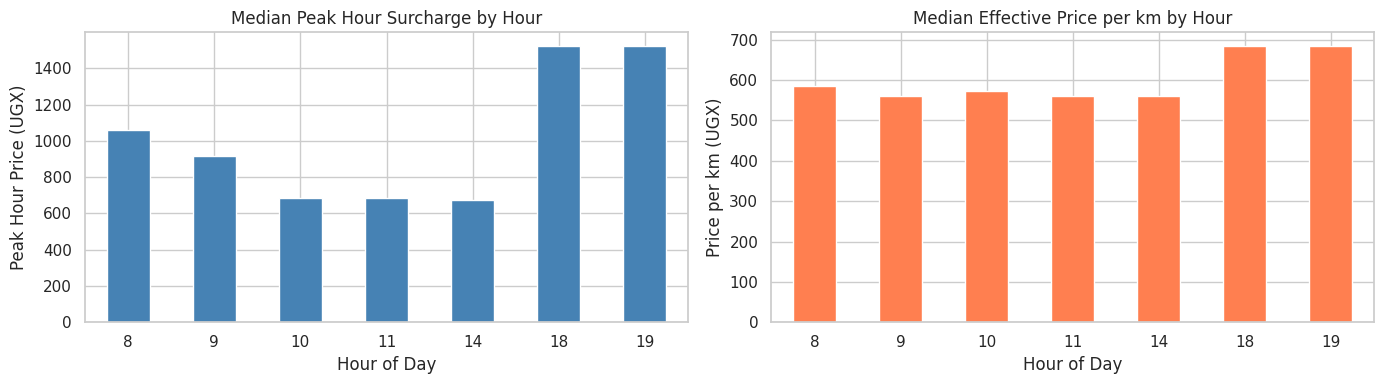

Summary statistics by time bucket:
                  peak_hour_price_ugx                       \
                               median    mean    std count   
time_bucket                                                  
Morning (6-10)                 1048.5  1075.1  220.9    10   
Midday (10-14)                  684.0   682.5   90.8    13   
Afternoon (14-17)               673.0   706.0   60.2     5   
Evening (17-20)                1522.5  1527.8   59.4    22   

                  price_per_km_actual                     
                               median   mean   std count  
time_bucket                                               
Morning (6-10)                  586.3  587.6  65.0    10  
Midday (10-14)                  559.6  540.2  42.7    13  
Afternoon (14-17)               559.6  582.4  56.6     5  
Evening (17-20)                 684.0  689.2  42.8    22  


In [8]:
# Hourly median peak_hour_price
hourly = df.groupby('hour')[['peak_hour_price_ugx', 'price_per_km_actual']].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

hourly['peak_hour_price_ugx'].plot(kind='bar', ax=axes[0], color='steelblue', rot=0)
axes[0].set_title('Median Peak Hour Surcharge by Hour')
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Peak Hour Price (UGX)')

hourly['price_per_km_actual'].plot(kind='bar', ax=axes[1], color='coral', rot=0)
axes[1].set_title('Median Effective Price per km by Hour')
axes[1].set_xlabel('Hour of Day')
axes[1].set_ylabel('Price per km (UGX)')

plt.tight_layout()
plt.show()

print('Summary statistics by time bucket:')
print(
    df.groupby('time_bucket')[['peak_hour_price_ugx', 'price_per_km_actual']]
    .agg(['median', 'mean', 'std', 'count'])
    .round(1)
)

**Key finding — Time of Day:**

- **Evening trips (17:00–20:00)** carry by far the highest surge charge (~1,520 UGX) and effective price per km (~684 UGX/km).
- **Midday trips (10:00–14:00)** are cheapest (~680 UGX surge, ~540 UGX/km).
- Morning trips (6:00–10:00) fall in between (~1,060 UGX surge, ~586 UGX/km).
- The evening surge is roughly **2× the midday surge** — a very large effect.

## 5. Price Variation by Day of Week

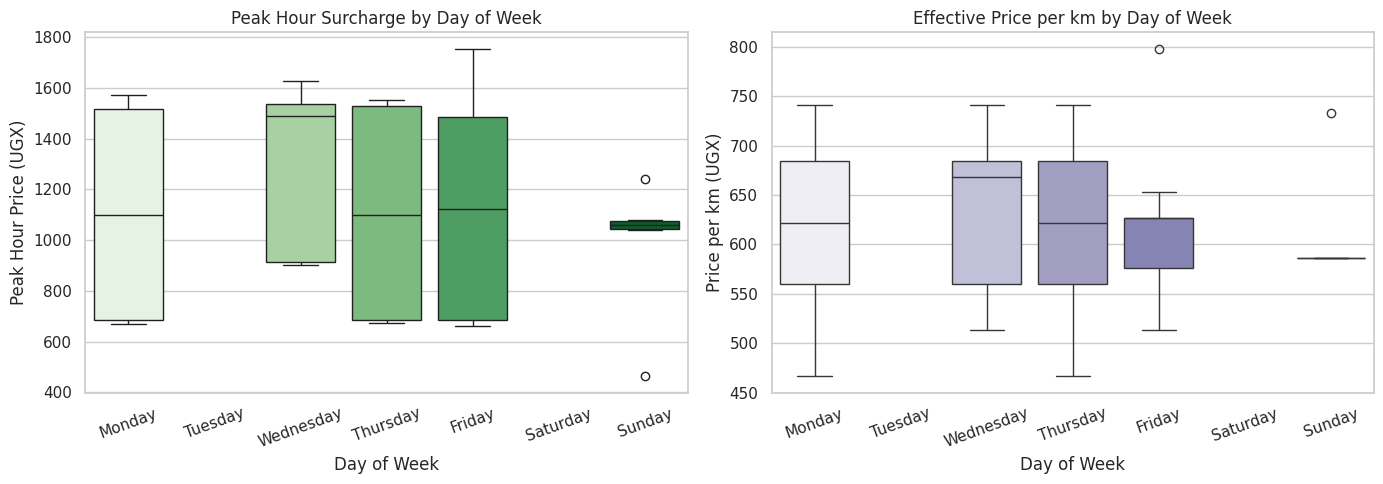

Summary statistics by day:
          peak_hour_price_ugx                      price_per_km_actual         \
                       median    mean    std count              median   mean   
day_name                                                                        
Monday                 1099.5  1106.8  446.8    10               621.8  618.2   
Wednesday              1488.0  1276.6  325.2    12               668.5  626.6   
Thursday               1099.5  1104.9  442.7    12               621.8  615.8   
Friday                 1123.0  1117.7  444.0    10               627.0  621.8   
Sunday                 1059.5   990.5  268.8     6               586.3  610.7   

                       
            std count  
day_name               
Monday     87.7    10  
Wednesday  79.5    12  
Thursday   98.7    12  
Friday     75.8    10  
Sunday     59.8     6  


In [9]:
days_present = [d for d in day_order if d in df['day_name'].cat.categories and d in df['day_name'].values]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df, x='day_name', y='peak_hour_price_ugx',
    order=day_order, ax=axes[0], palette='Greens'
)
axes[0].set_title('Peak Hour Surcharge by Day of Week')
axes[0].set_xlabel('Day of Week')
axes[0].set_ylabel('Peak Hour Price (UGX)')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(
    data=df, x='day_name', y='price_per_km_actual',
    order=day_order, ax=axes[1], palette='Purples'
)
axes[1].set_title('Effective Price per km by Day of Week')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Price per km (UGX)')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

print('Summary statistics by day:')
print(
    df.groupby('day_name')[['peak_hour_price_ugx', 'price_per_km_actual']]
    .agg(['median', 'mean', 'std', 'count'])
    .round(1)
)

**Key finding — Day of Week:**

- **Wednesday** stands out with the highest median peak surcharge (~1,488 UGX) and highest effective price per km (~668 UGX/km).
- **Thursday, Monday, Friday** are similar and moderate (~1,100 UGX surge).
- **Sunday** is the cheapest day (~990 UGX surge, ~586 UGX/km) — the lowest median across all days.
- The day-of-week effect is smaller than the time-of-day effect but still meaningful.

## 6. Combined Analysis: Day of Week × Time of Day

A heatmap shows how the surge charge varies across both dimensions simultaneously.

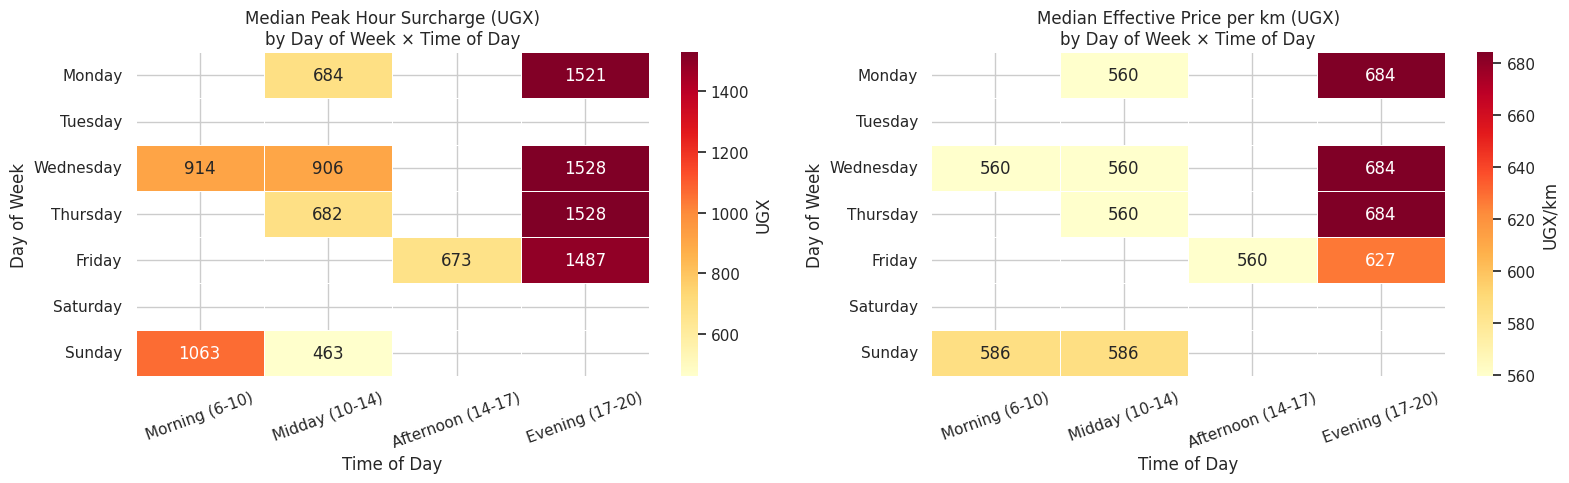

In [10]:
# Pivot table: median peak_hour_price by day and time bucket
pivot_peak = (
    df.groupby(['day_name', 'time_bucket'])['peak_hour_price_ugx']
    .median()
    .unstack('time_bucket')
    .reindex(day_order)
    [time_order]
)

pivot_perkm = (
    df.groupby(['day_name', 'time_bucket'])['price_per_km_actual']
    .median()
    .unstack('time_bucket')
    .reindex(day_order)
    [time_order]
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(
    pivot_peak, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[0], cbar_kws={'label': 'UGX'}
)
axes[0].set_title('Median Peak Hour Surcharge (UGX)\nby Day of Week × Time of Day')
axes[0].set_xlabel('Time of Day')
axes[0].set_ylabel('Day of Week')
axes[0].tick_params(axis='x', rotation=20)

sns.heatmap(
    pivot_perkm, annot=True, fmt='.0f', cmap='YlOrRd',
    linewidths=0.5, ax=axes[1], cbar_kws={'label': 'UGX/km'}
)
axes[1].set_title('Median Effective Price per km (UGX)\nby Day of Week × Time of Day')
axes[1].set_xlabel('Time of Day')
axes[1].set_ylabel('Day of Week')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

## 7. Identifying Peak Price Windows

Let's rank all day × time combinations to find the most and least expensive windows.

In [11]:
summary = (
    df.groupby(['day_name', 'time_bucket'])
    .agg(
        n_trips=('order_total_ugx', 'count'),
        median_peak_surcharge=('peak_hour_price_ugx', 'median'),
        mean_peak_surcharge=('peak_hour_price_ugx', 'mean'),
        median_price_per_km=('price_per_km_actual', 'median'),
    )
    .reset_index()
    .sort_values('median_peak_surcharge', ascending=False)
)

print('=== Top 5 MOST expensive day-time combinations ===')
print(summary.head(5).to_string(index=False))
print()
print('=== Top 5 CHEAPEST day-time combinations ===')
print(summary.tail(5).to_string(index=False))

=== Top 5 MOST expensive day-time combinations ===
 day_name     time_bucket  n_trips  median_peak_surcharge  mean_peak_surcharge  median_price_per_km
Wednesday Evening (17-20)        6                 1528.5          1523.666667           684.000000
 Thursday Evening (17-20)        6                 1527.5          1528.666667           684.000000
   Monday Evening (17-20)        5                 1521.0          1530.200000           684.000000
   Friday Evening (17-20)        5                 1487.0          1529.400000           627.000000
   Sunday  Morning (6-10)        5                 1063.0          1096.000000           586.285714

=== Top 5 CHEAPEST day-time combinations ===
 day_name       time_bucket  n_trips  median_peak_surcharge  mean_peak_surcharge  median_price_per_km
Wednesday    Midday (10-14)        1                  906.0           906.000000           559.636364
   Monday    Midday (10-14)        5                  684.0           683.400000           559.6363

## 8. Formally Controlling for Distance (OLS Regression)

To rigorously control for distance, we run an OLS regression with `order_total_ugx` as the outcome and `distance_km`, `time_bucket`, and `day_name` as predictors. The coefficients on time and day reflect price differences *after holding distance constant*.

In [12]:
try:
    import statsmodels.formula.api as smf

    # Build formula with distance controlled
    model = smf.ols(
        'order_total_ugx ~ distance_km + C(time_bucket) + C(day_name)',
        data=df
    ).fit()

    print(model.summary())
except ImportError:
    print('statsmodels not installed — skipping OLS regression.')

                            OLS Regression Results                            
Dep. Variable:        order_total_ugx   R-squared:                       0.688
Model:                            OLS   Adj. R-squared:                  0.628
Method:                 Least Squares   F-statistic:                     11.32
Date:                Wed, 01 Apr 2026   Prob (F-statistic):           2.75e-08
Time:                        15:19:51   Log-Likelihood:                -372.71
No. Observations:                  50   AIC:                             763.4
Df Residuals:                      41   BIC:                             780.6
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
In

**Interpretation:** The OLS coefficients on `C(time_bucket)` and `C(day_name)` show the estimated price difference attributable purely to *when* the trip was taken, with distance held constant. Positive coefficients confirm that Evening and Wednesday trips cost more even after accounting for distance.

## 9. Outliers and Special Cases

In [13]:
# Flag trips where order_total deviates a lot from distance-group median
median_by_dist = df.groupby('distance_km')['order_total_ugx'].transform('median')
df['deviation_from_median'] = df['order_total_ugx'] - median_by_dist

print('Trips with highest positive deviation (paid much more than typical):')
print(
    df[['date', 'time', 'day_name', 'time_bucket', 'distance_km',
        'order_total_ugx', 'peak_hour_price_ugx', 'deviation_from_median']]
    .sort_values('deviation_from_median', ascending=False)
    .head(5)
    .to_string(index=False)
)

print()
print('Trips with lowest deviation (best value):')
print(
    df[['date', 'time', 'day_name', 'time_bucket', 'distance_km',
        'order_total_ugx', 'peak_hour_price_ugx', 'deviation_from_median']]
    .sort_values('deviation_from_median')
    .head(5)
    .to_string(index=False)
)

Trips with highest positive deviation (paid much more than typical):
      date  time  day_name       time_bucket  distance_km  order_total_ugx  peak_hour_price_ugx  deviation_from_median
2026-02-13 19:13    Friday   Evening (17-20)            9             7182                 1754                 1026.0
2026-02-13 14:20    Friday Afternoon (14-17)           11             7182                  804                 1026.0
2026-02-18 09:10 Wednesday    Morning (6-10)           11             7182                 1625                 1026.0
2026-02-15 09:10    Sunday    Morning (6-10)            7             5130                 1242                 1026.0
2026-03-26 18:48  Thursday   Evening (17-20)            9             6669                 1550                  513.0

Trips with lowest deviation (best value):
      date  time  day_name       time_bucket  distance_km  order_total_ugx  peak_hour_price_ugx  deviation_from_median
2026-03-26 11:14  Thursday    Midday (10-14)           

## 10. Conclusions

### Answer to the main question:
*"For my own SafeBoda trips, after controlling for distance, how do prices vary by time of day and day of week?"*

#### Time of Day
Time of day is the **dominant driver** of price variation after controlling for distance:

| Time Bucket | Median Peak Surcharge | Median Price/km |
|-------------|----------------------|-----------------|
| Morning (6–10) | ~1,060 UGX | ~586 UGX/km |
| Midday (10–14) | ~684 UGX | ~541 UGX/km |
| Afternoon (14–17) | ~673 UGX | ~560 UGX/km |
| **Evening (17–20)** | **~1,522 UGX** | **~684 UGX/km** |

Evening trips cost approximately **2× more** in surge charges than midday trips. The difference in effective price per km between evening (~684) and midday (~541) is about **26%**.

#### Day of Week
Day of week has a secondary but real effect:

| Day | Median Peak Surcharge |
|-----|-----------------------|
| **Wednesday** | **~1,488 UGX** (highest) |
| Thursday / Monday / Friday | ~1,100 UGX |
| Sunday | ~991 UGX (lowest) |

#### Combined Effect
The most expensive window is **Wednesday evenings**, and the cheapest windows are **midday/afternoon on any weekday** (especially Sunday). My suspicion was correct — both time of day and day of week affect prices, with evening hours being by far the bigger factor.

#### Practical Takeaway
> 💡 **Travelling at midday or in the afternoon instead of the evening can save roughly 26% per km.** Avoiding Wednesday evenings in particular offers the best savings.

*Note: The dataset covers 50 trips across 5 weeks. Patterns are consistent but a larger dataset would give more statistical power, particularly for day-of-week estimates.*